# Pneumonia Detection using Chest X-Rays

### Setup

#### Setup the Environment

run the following command
```bash
conda create -n 10701-project python=3.14.4
conda activate 10701-project
pip install -r requirements.txt
```
then, open this notebook and use this environemnt `10701-project` from the kernel selector.

#### Download Data

In [ ]:
# import kagglehub
# kagglehub.dataset_download("yusufmurtaza01/chest-xray-pneumonia-balanced-dataset", output_dir="./data")
# root = "./data"
# print("Path to dataset files:", root)

In [ ]:
root = "./data"

In [ ]:
pwd

'c:\\Users\\topaz\\Documents\\work\\10701-proj\\10701-project'

### Part 1. Logistics Regression

#### Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from utils.loader import load_data
from utils.image import preprocess_image
from utils.metric import calculate_metrics, print_metrics, plot_ROC
from utils.validation import KFolder
from models.LinearModel import LinearModel, Ridge

np.random.seed(42)

#### Load Data

In [ ]:
data_path = os.path.join(root)
train_data, train_labels = load_data(os.path.join(data_path, "train"))
val_data, val_labels = load_data(os.path.join(data_path, "val"))
test_data, test_labels = load_data(os.path.join(data_path, "test"))

Loading PNEUMONIA images from ./data\test: 100%|██████████| 15/15 [00:00<00:00, 415.15it/s]


We don't need a validation set for this task, instead we will not use validation(for logistics regression) or use cross-validation(regularized regression)

In [ ]:
train_data = train_data + val_data
train_labels = train_labels + val_labels

We are almost in a $p > n$ regime...

In [ ]:
print("Training data size:", len(train_data))
print("Test data size:", len(test_data))

Training data size: 8500
Test data size: 30


Example of a normal and pneumonia image

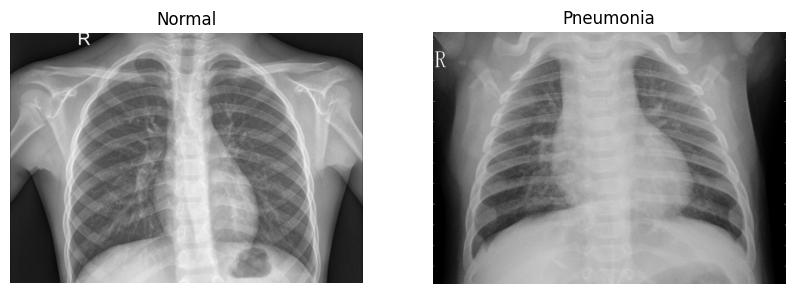

In [ ]:
normal_example = train_data[train_labels.index(0)]
pneumonia_example = train_data[train_labels.index(1)]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normal_example, cmap="gray")
plt.title("Normal")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pneumonia_example, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")
plt.show()

#### Preprocess Images

In [ ]:
train_data = [preprocess_image(img) for img in tqdm(train_data, desc="Preprocessing train images")]
test_data = [preprocess_image(img) for img in tqdm(test_data, desc="Preprocessing test images")]

Preprocessing test images: 100%|██████████| 30/30 [00:00<00:00, 72.91it/s]


Show resized image

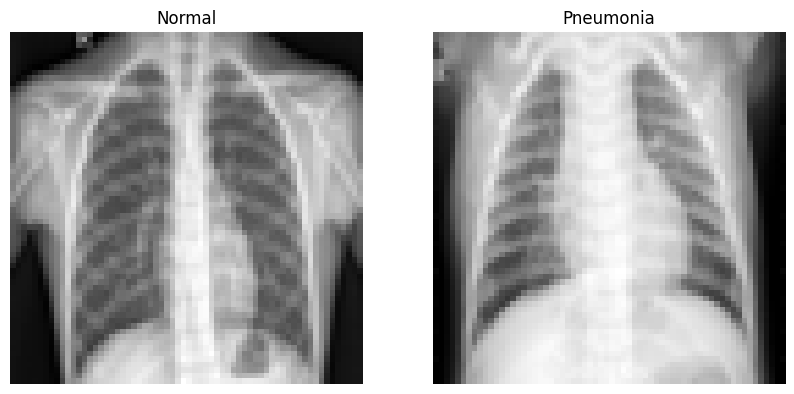

In [ ]:
normal_example = train_data[train_labels.index(0)]
pneumonia_example = train_data[train_labels.index(1)]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normal_example.reshape(64, 64), cmap="gray")
plt.title("Normal")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pneumonia_example.reshape(64, 64), cmap="gray")
plt.title("Pneumonia")
plt.axis("off")
plt.show()

#### Fit Logistics Regression Model

In [ ]:
LR_model = LinearModel(64 * 64)
LR_model.fit(np.array(train_data), np.array(train_labels), learning_rate=0.05, num_iterations=1000, tolerance=1e-3)
train_preds = LR_model.predict(np.array(train_data))
test_preds = LR_model.predict(np.array(test_data))

Training Linear Model, loss:1.4840:   0%|          | 2/1000 [00:00<03:01,  5.50it/s]

Iteration 0, Loss: 1.4840


Training Linear Model, loss:0.2426:  10%|█         | 102/1000 [00:15<02:17,  6.54it/s]

Iteration 100, Loss: 0.2426


Training Linear Model, loss:0.1858:  20%|██        | 202/1000 [00:29<01:51,  7.13it/s]

...

Iteration 800, Loss: 0.1277


Training Linear Model, loss:0.1464:  90%|█████████ | 902/1000 [02:03<00:13,  7.41it/s]

Iteration 900, Loss: 0.1464


Training Linear Model, loss:0.1370: 100%|██████████| 1000/1000 [02:16<00:00,  7.32it/s]


Final Loss: 0.1363


This simple full-batch gradient descend is not very stable... might want to consider implementing second-order methods.

#### Evaluate Fit

In [ ]:
print_metrics(np.array(train_labels), train_preds)
print_metrics(np.array(test_labels), test_preds)

Accuracy: 0.9480
Precision: 0.9472
Recall: 0.9489
F1 Score: 0.9480
Confusion Matrix:
[[4025  225]
 [ 217 4033]]
Accuracy: 0.8667
Precision: 0.8235
Recall: 0.9333
F1 Score: 0.8750
Confusion Matrix:
[[12  3]
 [ 1 14]]


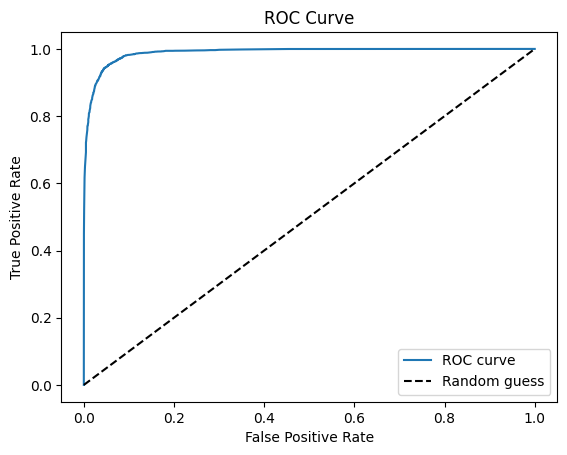

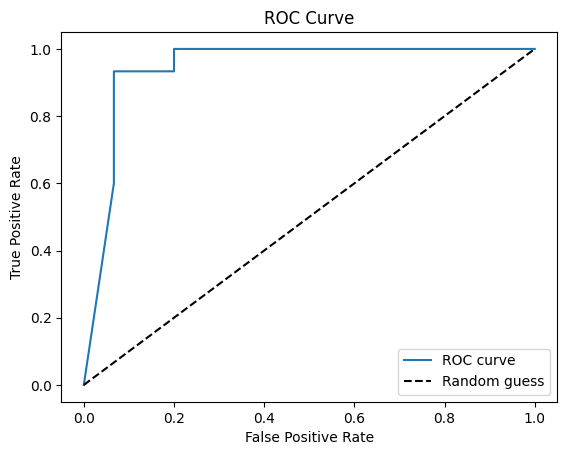

In [ ]:
plot_ROC(np.array(train_labels), LR_model.prob(np.array(train_data)))
plot_ROC(np.array(test_labels), LR_model.prob(np.array(test_data)))

### Part 2. Lasso Regression with Cross-Validation

In [ ]:
lambda_values = np.logspace(-6, -1, 10)
print("Lambda values to try:", lambda_values)

Lambda values to try: [1.00000000e-06 3.59381366e-06 1.29154967e-05 4.64158883e-05
 1.66810054e-04 5.99484250e-04 2.15443469e-03 7.74263683e-03
 2.78255940e-02 1.00000000e-01]


In [ ]:
Kf = KFolder(np.array(train_data), np.array(train_labels), k = 5)

In [ ]:
train_loss = []
val_loss = []
for lambda_ in lambda_values:
    fold_train_loss = []
    fold_val_loss = []
    for fold, (X_train, y_train, X_val, y_val) in enumerate(Kf.split()):
        model = Ridge(64 * 64, lambda_)
        model.fit(X_train, y_train, learning_rate=0.01, num_iterations=5000, tolerance=1e-3)
        train_loss_fold = model.compute_loss_no_reg(X_train, y_train)
        val_loss_fold = model.compute_loss_no_reg(X_val, y_val)
        fold_train_loss.append(train_loss_fold)
        fold_val_loss.append(val_loss_fold)
        print(f"Lambda: {lambda_:.4f}, Fold: {fold + 1}, Train Loss: {train_loss_fold:.4f}, Val Loss: {val_loss_fold:.4f}")
    avg_train_loss = np.mean(fold_train_loss)
    avg_val_loss = np.mean(fold_val_loss)
    train_loss.append(avg_train_loss)
    val_loss.append(avg_val_loss)
    print(f"---\nLambda: {lambda_:.4f}, Avg Train Loss: {avg_train_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}\n---")

Training Regularized Linear Model:   0%|          | 0/5000 [00:00<?, ?it/s]

Training Regularized Linear Model, loss:0.7318:   0%|          | 3/5000 [00:00<08:25,  9.88it/s]

Iteration 0, Loss: 0.7318


Training Regularized Linear Model, loss:0.3176:   2%|▏         | 103/5000 [00:10<08:20,  9.78it/s]

Iteration 100, Loss: 0.3176


...

Iteration 100, Loss: 0.3683


Training Regularized Linear Model, loss:0.3190:   4%|▍         | 201/5000 [00:38<18:24,  4.35it/s]

Iteration 200, Loss: 0.3190


Training Regularized Linear Model, loss:0.3028:   6%|▌         | 290/5000 [00:53<14:36,  5.37it/s]


KeyboardInterrupt: 

In [27]:
best_lambda = lambda_values[np.argmin(val_loss)]
print(f"Best lambda: {best_lambda:.10f}")

Best lambda: 0.0000010000


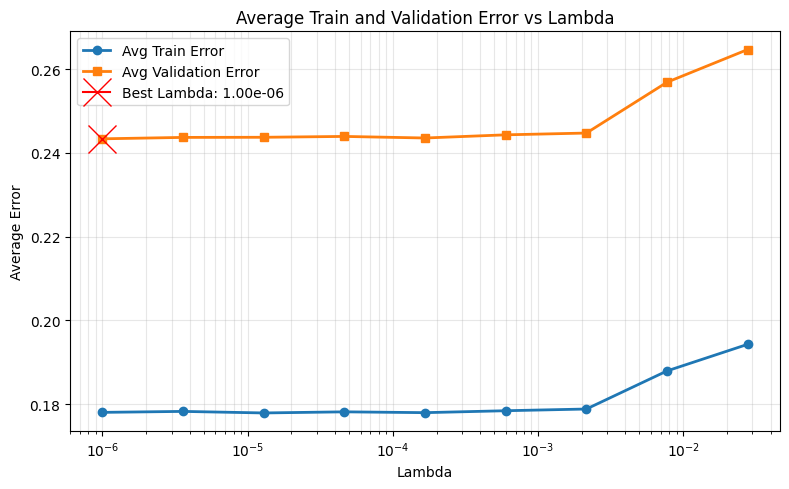

In [ ]:
def plot_avg_error_vs_lambda(lambda_values, train_errors, val_errors, use_log_scale=True):
    """Plot average train and validation error as a function of lambda."""
    lambda_values = np.asarray(lambda_values)
    train_errors = np.asarray(train_errors)
    val_errors = np.asarray(val_errors)

    if not (len(lambda_values) == len(train_errors) == len(val_errors)):
        raise ValueError("lambda_values, train_errors, and val_errors must have the same length")

    plt.figure(figsize=(8, 5))
    plt.plot(lambda_values, train_errors, marker="o", linewidth=2, label="Avg Train Error")
    plt.plot(lambda_values, val_errors, marker="s", linewidth=2, label="Avg Validation Error")
    plt.plot(best_lambda, val_errors[np.argmin(val_errors)], marker="x", markersize=20, color="red", label=f"Best Lambda: {best_lambda:.2e}")

    if use_log_scale:
        plt.xscale("log")

    plt.xlabel("Lambda")
    plt.ylabel("Average Error")
    plt.title("Average Train and Validation Error vs Lambda")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_avg_error_vs_lambda(lambda_values, train_loss, val_loss)

In [32]:
# retrain with best lambda
final_model = Ridge(64 * 64, best_lambda)
final_model.fit(np.array(train_data), np.array(train_labels), learning_rate=0.01, num_iterations=1000)
train_preds = final_model.predict(np.array(train_data))
test_preds = final_model.predict(np.array(test_data))

Training Regularized Linear Model, loss:0.7043:   0%|          | 1/1000 [00:00<07:51,  2.12it/s]

Iteration 0, Loss: 0.7043


Training Regularized Linear Model, loss:0.3241:  10%|█         | 101/1000 [00:27<04:41,  3.20it/s]

Iteration 100, Loss: 0.3241


Training Regularized Linear Model, loss:0.2617:  20%|██        | 202/1000 [00:56<03:31,  3.77it/s]

...

Iteration 800, Loss: 0.1765


Training Regularized Linear Model, loss:0.1716:  90%|█████████ | 901/1000 [04:05<00:30,  3.20it/s]

Iteration 900, Loss: 0.1716


Training Regularized Linear Model, loss:0.1679: 100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]


Final Loss: 0.1675


In [33]:
print_metrics(np.array(train_labels), train_preds)
print_metrics(np.array(test_labels), test_preds)

Accuracy: 0.9428
Precision: 0.9391
Recall: 0.9471
F1 Score: 0.9431
Confusion Matrix:
[[3989  261]
 [ 225 4025]]
Accuracy: 0.8667
Precision: 0.8235
Recall: 0.9333
F1 Score: 0.8750
Confusion Matrix:
[[12  3]
 [ 1 14]]


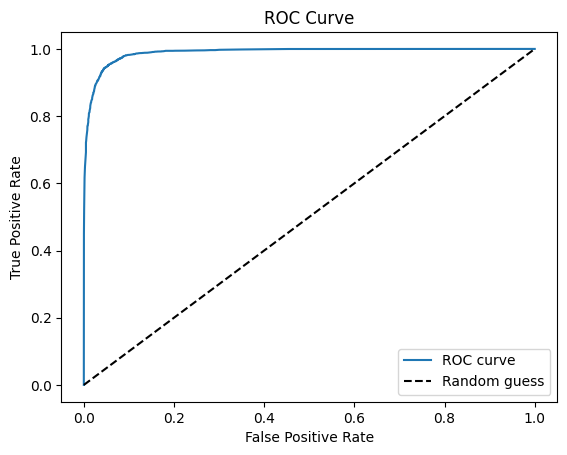

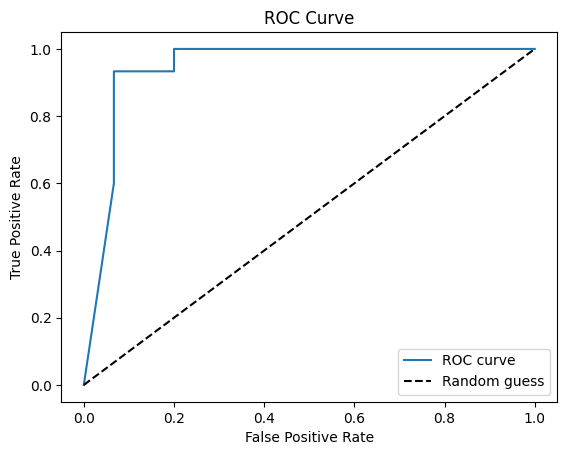

In [34]:
plot_ROC(np.array(train_labels), LR_model.prob(np.array(train_data)))
plot_ROC(np.array(test_labels), LR_model.prob(np.array(test_data)))

The result is identical to logistics regression on all pixels.